# Unidad 1: Duopolio de Cournot

### Supuestos del modelo
* Dos empresas producen un bien homogéneo: $Q = q_1 + q_2$.
* Demanda inversa de mercado: $P(Q) = 100 - Q$.
* Costos marginales constantes: $c_1 = c_2 = 10$.

### Condición de Primer Orden (CPO)
Cada firma maximiza beneficios tomando como dada la cantidad del rival:
$$ \max_{q_1} \pi_1 = (100 - q_1 - q_2 - 10)q_1 $$
$$ \frac{\partial \pi_1}{\partial q_1} = 90 - 2q_1 - q_2 = 0 \implies q_1^*(q_2) = \frac{90 - q_2}{2} $$


In [13]:
import sympy as sp

# Definimos las variables simbólicas
q1, q2 = sp.symbols('q1 q2')

# Asignamos la función de beneficios (con un solo '=')
pi1 = (100 - q1 - q2 - 10) * q1

# Condición de Primer Orden: derivar respecto a q1
cpo1 = sp.diff(pi1, q1)

# Despejar q1 de la CPO: cpo1 = 0
reaccion1 = sp.solve(cpo1, q1)[0]

print("Función de mejor respuesta q1(q2):", reaccion1)

Función de mejor respuesta q1(q2): 45 - q2/2


In [14]:
# 1. Definimos la CPO y función de mejor respuesta para la Empresa 2 (simétrica)
pi2 = (100 - q1 - q2 - 10) * q2
cpo2 = sp.diff(pi2, q2)
reaccion2 = sp.solve(cpo2, q2)[0]

# 2. Resolvemos el sistema de 2 ecuaciones con 2 incógnitas
equilibrio = sp.solve([sp.Eq(q1, reaccion1), sp.Eq(q2, reaccion2)], (q1, q2))

q1_star = float(equilibrio[q1])
q2_star = float(equilibrio[q2])
Q_total = q1_star + q2_star
precio = 100 - Q_total

print(f"--- EQUILIBRIO DE COURNOT ---")
print(f"Cantidad Empresa 1 (q1*): {q1_star}")
print(f"Cantidad Empresa 2 (q2*): {q2_star}")
print(f"Producción Total (Q*): {Q_total}")
print(f"Precio de Mercado (P*): ${precio}")

--- EQUILIBRIO DE COURNOT ---
Cantidad Empresa 1 (q1*): 30.0
Cantidad Empresa 2 (q2*): 30.0
Producción Total (Q*): 60.0
Precio de Mercado (P*): $40.0


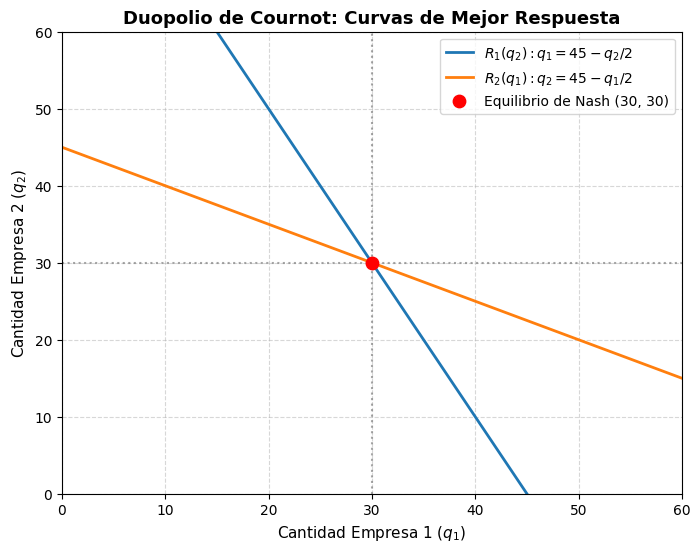

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Convertimos las funciones simbólicas a funciones numéricas evaluables
f_r1 = sp.lambdify(q2, reaccion1, 'numpy')
f_r2 = sp.lambdify(q1, reaccion2, 'numpy')

# 2. Vector de cantidades para el eje horizontal (q1)
q_grid = np.linspace(0, 60, 200)

# Curva 1: q2 despejada a partir de q1 = 45 - q2/2  =>  q2 = 90 - 2*q1
q2_de_r1 = 90 - 2 * q_grid

# Curva 2: q2 = 45 - q1/2 directa
q2_de_r2 = f_r2(q_grid)

# 3. Construcción del gráfico
plt.figure(figsize=(8, 6))

plt.plot(q_grid, q2_de_r1, label=r'$R_1(q_2): q_1 = 45 - q_2/2$', color='#1f77b4', linewidth=2)
plt.plot(q_grid, q2_de_r2, label=r'$R_2(q_1): q_2 = 45 - q_1/2$', color='#ff7f0e', linewidth=2)

# Punto de equilibrio de Nash (30, 30)
plt.scatter([q1_star], [q2_star], color='red', s=80, zorder=5, label=f'Equilibrio de Nash ({q1_star:.0f}, {q2_star:.0f})')

# Líneas punteadas hacia los ejes
plt.axvline(x=q1_star, color='gray', linestyle=':', alpha=0.7)
plt.axhline(y=q2_star, color='gray', linestyle=':', alpha=0.7)

# Configuración de límites y etiquetas
plt.xlim(0, 60)
plt.ylim(0, 60)
plt.xlabel('Cantidad Empresa 1 ($q_1$)', fontsize=11)
plt.ylabel('Cantidad Empresa 2 ($q_2$)', fontsize=11)
plt.title('Duopolio de Cournot: Curvas de Mejor Respuesta', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, loc='upper right')

plt.show()